In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [ ]:
titanic= sns.load_dataset("titanic")

In [ ]:
titanic.head()
titanic.info()
titanic.isnull().sum()
  

In [ ]:
#  fill up the missing value
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
titanic[['age']]= imp_median.fit_transform(titanic[['age']])

imp_freq= SimpleImputer(strategy="most_frequent")
titanic[['embarked']]=imp_freq.fit_transform(titanic[['embarked']])


In [ ]:
titanic.isnull().sum()
titanic.shape

In [ ]:
# encode
# label encoding for sex feature  
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked']=le.fit_transform(titanic['embarked'])


In [ ]:
 #  select the features we want to Use
features=["pclass","sex","fare","embarked","age"]
target=['survived']


X=titanic[features]
y=titanic[target]

In [ ]:
X.head()

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(
    X,y,test_size=0.2, random_state=42
)

# Build A Decision Tree Simple model without pruning

In [ ]:

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier() # no pruning

model.fit(X_train,y_train)
 

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)
print(f"Accuracy for our model : {accuracy_score(y_test,y_pred)}")


# plot tree 

In [ ]:
 
from sklearn.tree import plot_tree

plt.figure(figsize=(18,12))
plot_tree(
    model,
    feature_names=X.columns,
    class_names= ["Died","Survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()


##  Decision Tree With Pre Pruning

For depth : 2 -> Accuracy Score :0.7653631284916201
For depth : 3 -> Accuracy Score :0.7988826815642458
For depth : 4 -> Accuracy Score :0.7988826815642458


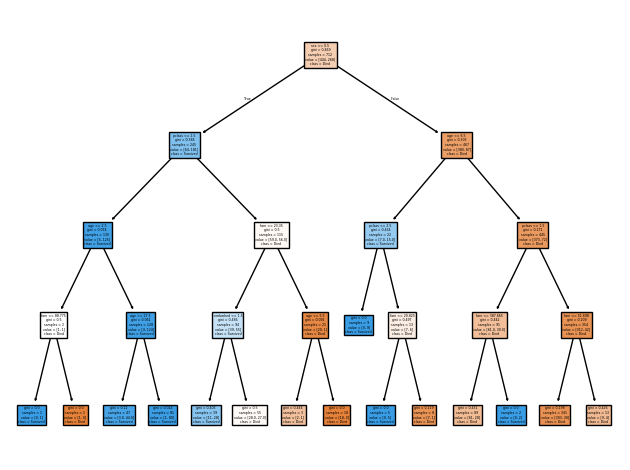

For depth : 5 -> Accuracy Score :0.7988826815642458
For depth : 6 -> Accuracy Score :0.7988826815642458
For depth : 7 -> Accuracy Score :0.7932960893854749
For depth : 8 -> Accuracy Score :0.7932960893854749
For depth : 9 -> Accuracy Score :0.7932960893854749
For depth : 10 -> Accuracy Score :0.7877094972067039


In [57]:

# Build A Decision Tree Simple model with Pre pruning
from sklearn.tree import DecisionTreeClassifier


max_depth=[2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)
    accuracy_sc= model.score(X_test,y_test)
    print(f"For depth : {depth} -> Accuracy Score :{accuracy_sc}")

    if depth==4:
        plot_tree(model,feature_names=X.columns,class_names= ["Died","Survived"],filled=True)
        plt.tight_layout()
        plt.show()

    

In [ ]:

# Build A Decision Tree Simple model with Pre pruning
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=4)
model.fit(X_train,y_train)

accuracy_sc= model.score(X_test,y_test)
print(f"For depth : {4} -> Accuracy Score :{accuracy_sc}") 

For  Sample Split : 5 -> Accuracy Score :0.7988826815642458
For  Sample Split : 10 -> Accuracy Score :0.7988826815642458


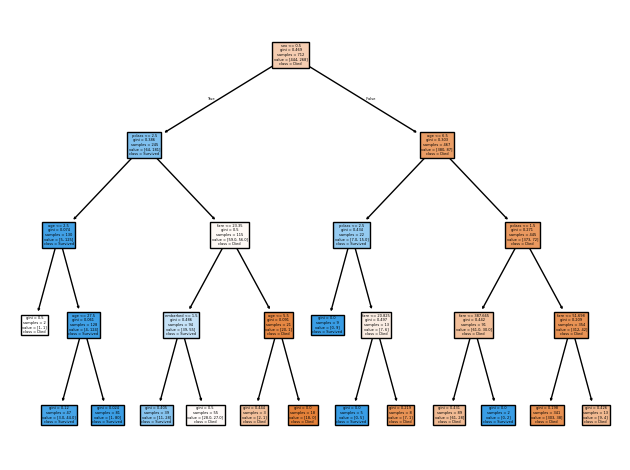

For  Sample Split : 15 -> Accuracy Score :0.7988826815642458
For  Sample Split : 20 -> Accuracy Score :0.7988826815642458
For  Sample Split : 25 -> Accuracy Score :0.7932960893854749
For  Sample Split : 30 -> Accuracy Score :0.7932960893854749


In [56]:

# Build A Decision Tree Simple model with Pre pruning
from sklearn.tree import DecisionTreeClassifier

min_samples_splits=[5,10,15,20,25,30]

for split in min_samples_splits:
    model=DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    
    model.fit(X_train,y_train)
    accuracy_sc= model.score(X_test,y_test)
    print(f"For  Sample Split : {split} -> Accuracy Score :{accuracy_sc}")

    if split==10:
        plot_tree(model,feature_names=X.columns,class_names= ["Died","Survived"],filled=True)
        plt.tight_layout()
        plt.show()



## Decision Tree With Post Pruning



In [60]:
full_tree= DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train) # based on training data
ccp_alphas=path.ccp_alphas 
# print(ccp_alphas)
#  want to remove that subtree that have complexity high

# to pick the best alpha value train our model all alphas
trees=[]
for alpha in ccp_alphas:
    model= DecisionTreeClassifier(random_state=42,ccp_alpha=alpha )
    model.fit(X_train,y_train)
    trees.append((model,alpha))



In [74]:
best_acc=0

best_alpha=0

for model,alpha in trees:
    current_acc=model.score(X_test,y_test)
    if current_acc >best_acc:
        best_acc= current_acc
        best_alpha= alpha
        
print(f"BEST APLHA: {best_alpha}")
print(f"BEST ACCURACY : {best_acc}")


BEST APLHA: 0.0015407231242023183
BEST ACCURACY : 0.8379888268156425


In [75]:
best_model= DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


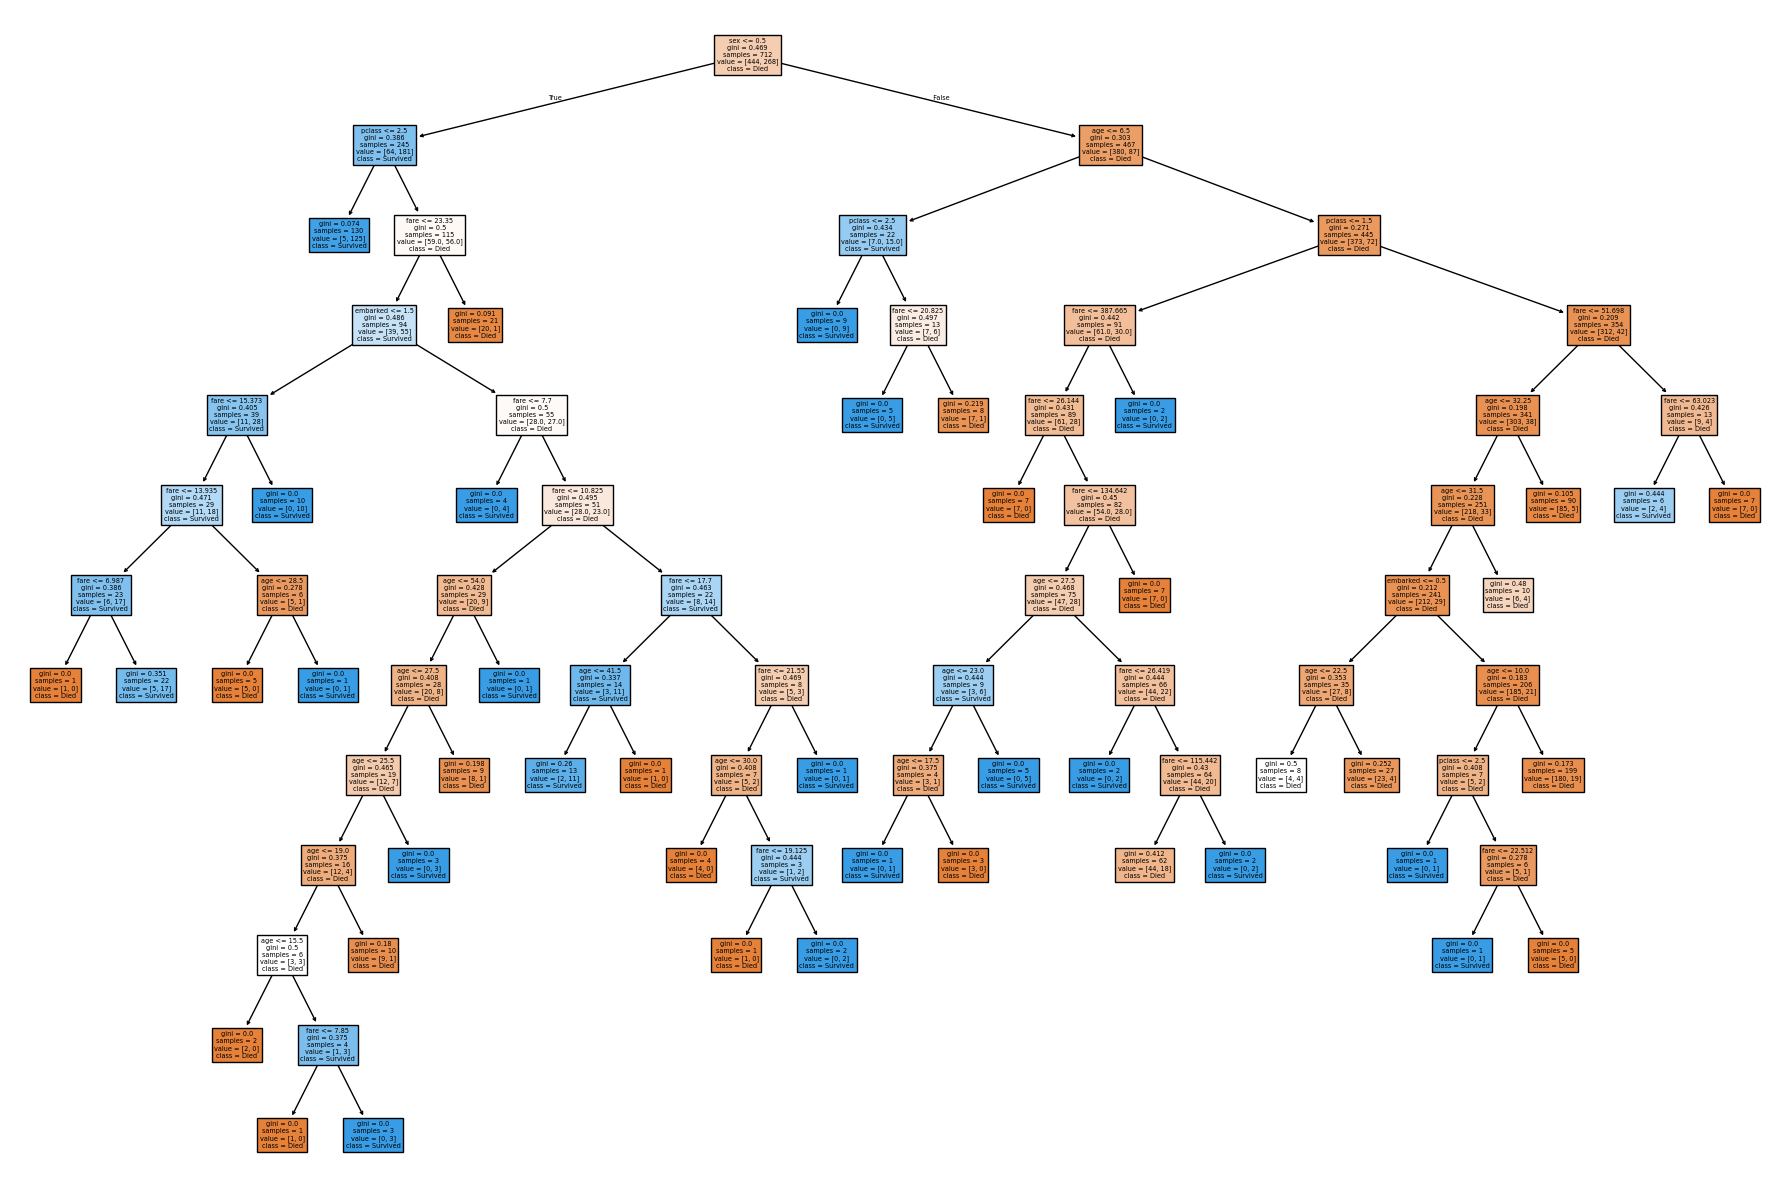

In [79]:
plt.figure(figsize=(18,12))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names= ["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()


In [77]:
print(best_model.score(X_test,y_test))

0.8379888268156425


In [80]:
best_model= DecisionTreeClassifier(ccp_alpha=best_alpha, max_depth=4)
best_model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


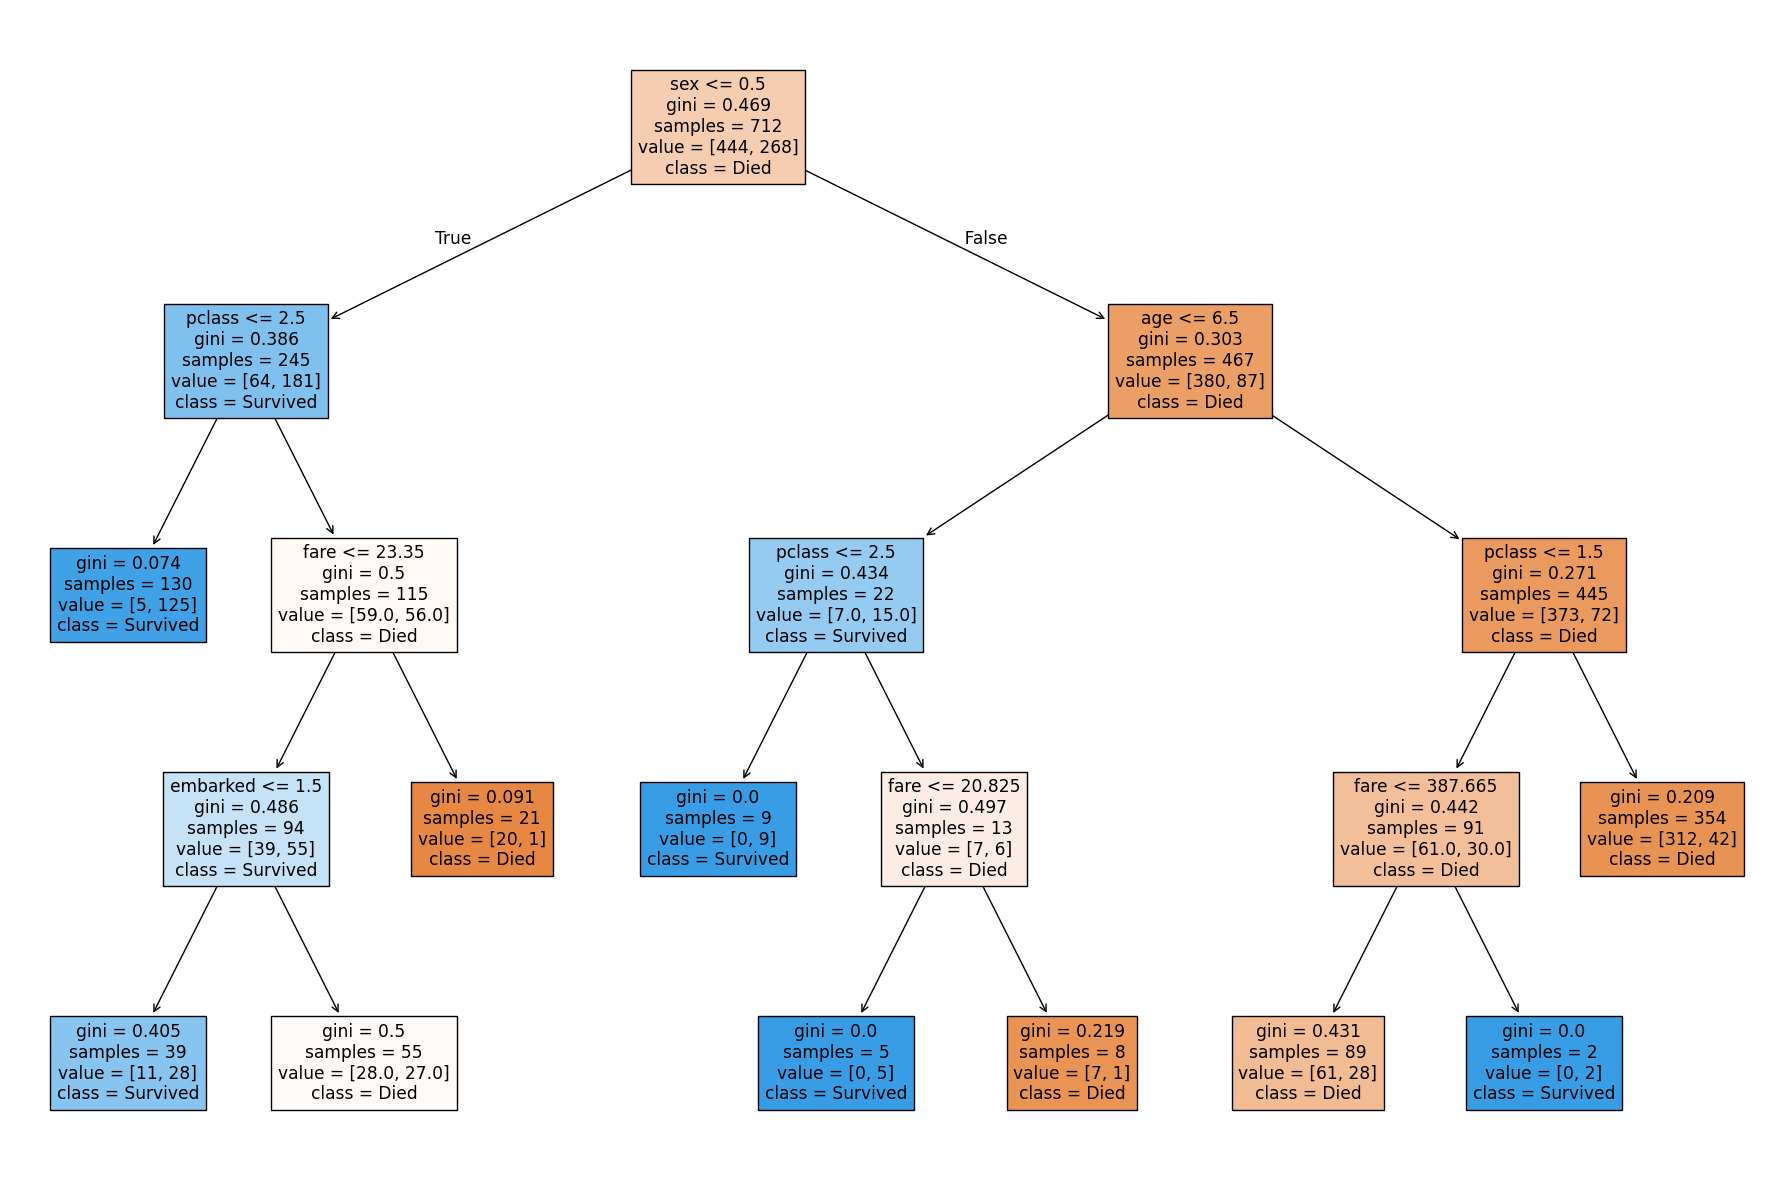

In [81]:
plt.figure(figsize=(18,12))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names= ["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()
